# Step 3: Database Population (ETL)

This notebook implements the full ETL pipeline for the parking spaces data layer:

* Extracts raw sources

* Applies the finalized transformation & unification logic from Step 2

* Loads the unified dataset into the Postgres database and runs QA checks.

See notebooks for decision making process: 

* `parking_spaces/scripts/parking_spaces_data_modelling`

* `parking_spaces/scripts/parking_spaces_data_transformation`


# Setting Up Environment

In this section we load the imports, constants, and functions that are needed for the full ETL process of parking data into the layered database. 

## Imports

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import os
import re

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.ops import unary_union
import osmnx as ox
from typing import Union, cast
from sqlalchemy import text

import psycopg2
import pandas as pd
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings("ignore")

## Constants

In [2]:
TARGET_CRS = "EPSG:4326"
SOURCES_DIR = Path("../sources")
RUN_TS = datetime.now(timezone.utc).isoformat()

pd.set_option("display.max_columns", 100)

In [3]:
TARGET_COLS = [
    "source",
    "source_layer",
    "external_id",
    "name",
    "parking_type",
    "operator",
    "fee",
    "time_restriction",
    "capacity",
    "capacity_disabled",
    "street_name",
    "district",
    "managed_zone_id",
    "geometry_type",
    "geometry",
    "last_updated_at_source",
    "fetched_at",
]

OSM_COLS_KEEP = [
    "geometry",
    "amenity",
    "parking",
    "name",
    "operator",
    "fee",
    "opening_hours",
    "capacity",
    "capacity_disabled",
    "addr_street",
]

ZONE_COLS_KEEP = [
    "id",        # original zone id
    "parkzone",  # human-readable id
    "bezirk",
    "zeiten",
    "gebuehr",
    "bemerkung",
]

## Helper Functions

In [4]:
# Function to load or fetch WFS data
def load_or_fetch_wfs(local_name: str, wfs_url: str) -> gpd.GeoDataFrame:
    """
    Load a GeoJSON from /sources if present, otherwise fetch from WFS,
    save it, and return as GeoDataFrame in TARGET_CRS.
    """
    local_path = SOURCES_DIR / local_name

    if local_path.exists():
        gdf = gpd.read_file(local_path)
        print(f"➡️ loaded local {local_name} → {len(gdf)} rows")
    else:
        print(f"🌐 fetching from WFS → {wfs_url}")
        gdf = gpd.read_file(wfs_url)
        local_path.parent.mkdir(parents=True, exist_ok=True)
        gdf.to_file(local_path, driver="GeoJSON")
        print(f"✅ saved to {local_path}")

    return gdf.to_crs(TARGET_CRS)

In [5]:
# Function to ensure a column exists in a DataFrame
def ensure_column(df, col, default=pd.NA):
    """Add column if missing, with a default value."""
    if col not in df.columns:
        df[col] = default
    return df

In [6]:
# Function to load Berlin street parking data
def load_berlin_street_parking():
    """
    Load Berlin street parking (inside + outside S-Bahn ring).
    If local cached file exists, use it.
    Otherwise fetch the two WFS layers separately and merge.
    """
    local_path = SOURCES_DIR / "bod_parking_street.geojson"
    if local_path.exists():
        print(f"📁 loading local street parking → {local_path}")
        gdf = gpd.read_file(local_path).to_crs(TARGET_CRS)
        return gdf

    base = "https://gdi.berlin.de/services/wfs/parkplaetze"
    common = "?service=WFS&version=2.0.0&request=GetFeature&outputFormat=application/json"

    inside_url = base + common + "&typeNames=parkplaetze:parkplaetze"
    outside_url = base + common + "&typeNames=parkplaetze:parkplaetze_aussen"

    print("🌐 fetching inside ring…")
    gdf_inside = gpd.read_file(inside_url)
    print("🌐 fetching outside ring…")
    gdf_outside = gpd.read_file(outside_url)

    parking_all = gpd.GeoDataFrame(
        pd.concat([gdf_inside, gdf_outside], ignore_index=True),
        crs=gdf_inside.crs,
    ).to_crs(TARGET_CRS)

    # cache it
    local_path.parent.mkdir(parents=True, exist_ok=True)
    parking_all.to_file(local_path, driver="GeoJSON")
    print(f"💾 cached merged street parking → {local_path}")

    return parking_all

In [7]:
# Function to standardize column names 
def clean_column_names(name: str) -> str:
    name = name.strip()                                   # remove leading and trailing white space
    name = re.sub(r"[^\w]+", "_", name)                   # replace special characters
    name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", name)   # handle camelcase and pascalcase 
    return name.lower().strip("_")                        # lowercase and remove leading and trailing underscores

In [8]:
# Function to show duplicate columns 
def show_dupes(df, name):
    dupes = df.columns[df.columns.duplicated()].tolist()
    print(f"{name} duplicate cols:", dupes)

In [9]:
# Constants for parse fee token function
FREE_TOKENS = {
    "no","none","kein","kostenlos","gratis","free",
    "0","0€","0 eur","0 euro","0.0","0,0"
}
PAID_TOKENS = {"yes","ja","paid","gebührenpflichtig","entgeltpflichtig"}

# Function to parse fee token
def parse_fee_token(val):
    """
    Return (amount, status, note)
      status ∈ {"paid", "free", "unknown"}
      amount is float EUR or NaN
      note keeps ambiguous descriptive text
    Rules:
      - explicit FREE_TOKENS -> ("free", amount NaN)
      - numeric(s) present -> use the **lowest** number as base amount
      - explicit PAID_TOKENS without number -> ("paid", amount NaN)
      - phrases like 'first 90min free, 1€/h after' -> ('paid', NaN, original text)
      - otherwise 'unknown'
    """
    if pd.isna(val):
        return (np.nan, "unknown", None)

    s = str(val).strip().lower()
    if s in FREE_TOKENS:
        return (np.nan, "free", None)
    if s in PAID_TOKENS:
        return (np.nan, "paid", s)

    # collect all numeric tokens (handles '3,00–4,00 Euro' -> ['3,00','4,00'])
    nums = re.findall(r'\d+[.,]?\d*', s)
    nums = [float(n.replace(",", ".")) for n in nums] if nums else []

    if nums:
        base = min(nums)           # take the lowest as base amount
        if base > 0:
            return (base, "paid", s)
        else:
            return (np.nan, "free", s)

    # Ambiguous phrases like 'varies', 'first 90min free, 1€/h after'
    if any(k in s for k in ["varies", "per", "/h", "hour", "h after", "min free"]):
        return (np.nan, "paid", s)

    return (np.nan, "unknown", s)

# Extract - Load Raw Data Sources

Here we load all the raw Berlin parking related data that we will clean and unify later.

Sources:

* **Open Street Map** (amenity: parking, parking_space, and parking_entrance)

* **Berlin Open Data** (Parken im Straßenraum, Park and Ride Anlagen, and Parkraumbewirtschaftung)

## OSM Parking Related Data

**amenity**: parking, parking_space, and parking_entrance

In [10]:
TagValue = Union[bool, str, list[str]]

# Off-street style parking: amenity=parkin
tags_parking: dict[str, TagValue] = {"amenity": "parking"}
parking_gdf = ox.features_from_place("Berlin, Germany", tags_parking)
print(f"Off-street parking objects fetched: {len(parking_gdf)}")

# Individual/on-street parking spaces: amenity=parking_space
tags_parking_space: dict[str, TagValue] = {"amenity": "parking_space"}
parking_space_gdf = ox.features_from_place("Berlin, Germany", tags_parking_space)
print(f"Parking space objects fetched: {len(parking_space_gdf)}")

# Parking entrances (garages, underground, etc.)
tags_parking_entrance: dict[str, TagValue] = {"amenity": "parking_entrance"}
parking_entrance_gdf = ox.features_from_place("Berlin, Germany", tags_parking_entrance)
print(f"Parking entrance objects fetched: {len(parking_entrance_gdf)}")

Off-street parking objects fetched: 49049
Parking space objects fetched: 5284
Parking entrance objects fetched: 2489


## Berlin Open Data Parking Related Data

* Parken im Straßenraum (street parking)

* Park and Ride

* Parkraumbewirtschaftung (Managed Parking Zones)

In [11]:
# Berlin street parking (inside + outside Ring Bahn)
bod_parking_street = load_berlin_street_parking()

# Park & Ride
bod_park_and_ride = load_or_fetch_wfs(
    "bod_park_and_ride.geojson",
    (
        "https://gdi.berlin.de/services/wfs/park_and_ride"
        "?service=WFS&version=2.0.0&request=GetFeature"
        "&typenames=park_and_ride:park_and_ride"
        "&outputFormat=application/json"
    ),
)

# Managed parking zones
bod_parking_zones = load_or_fetch_wfs(
    "bod_parking_zones.geojson",
    (
        "https://gdi.berlin.de/services/wfs/parkraumbewirtschaftung"
        "?service=WFS&version=2.0.0&request=GetFeature"
        "&typenames=parkraumbewirtschaftung:parkzonen"
        "&outputFormat=application/json"
    ),
)

loaded = {
    "bod_parking_street": bod_parking_street,
    "bod_park_and_ride": bod_park_and_ride,
    "bod_parking_zones": bod_parking_zones,
}
print("✅ Loaded sources:", loaded.keys())

📁 loading local street parking → ../sources/bod_parking_street.geojson
➡️ loaded local bod_park_and_ride.geojson → 48 rows
➡️ loaded local bod_parking_zones.geojson → 94 rows
✅ Loaded sources: dict_keys(['bod_parking_street', 'bod_park_and_ride', 'bod_parking_zones'])


# Transform Data

In this section we perform data transformation and integration to get a final unified parking dataset.

* Normalize Columns Names

* Data Integration & Enrichment

* Duplicates

* Disctrict & Neighborhood Mapping

* Categorical Values

* Missing Street Names


## Normalize Column Names

We clean the columns in the raw datasets seperately and make sure they are in lower- and snakecase.

In [12]:
# standardize OSM columns
parking_gdf.columns = [clean_column_names(c) for c in parking_gdf.columns]
parking_space_gdf.columns = [clean_column_names(c) for c in parking_space_gdf.columns]
parking_entrance_gdf.columns = [clean_column_names(c) for c in parking_entrance_gdf.columns]

# standardize columns Berlin Open Data
for key, gdf in loaded.items():
    gdf.columns = [clean_column_names(c) for c in gdf.columns]
    loaded[key] = gdf

## Data Integration & Enrichment

Here we will combine all three layers of the OSM data and enrich it with the Berlin Open Data to create a unified dataset.

### Combine OSM Layers

In [13]:
# Ensure all are in WGS84
for gdf in [parking_gdf, parking_space_gdf, parking_entrance_gdf]:
    gdf.to_crs(TARGET_CRS, inplace=True)

# Add a parking_type column to keep them distinguishable
parking_gdf["parking_type"] = "off_street"
parking_space_gdf["parking_type"] = "on_street"
parking_entrance_gdf["parking_type"] = "entrance"

# Combine into one OSM GeoDataFrame
osm_all = pd.concat([parking_gdf, parking_space_gdf, parking_entrance_gdf], ignore_index=True)
osm_all = gpd.GeoDataFrame(osm_all, geometry="geometry", crs=TARGET_CRS)
print(f"✅ Combined OSM dataset: {len(osm_all)} records")

✅ Combined OSM dataset: 56822 records


### Enrich with Parking Zones

In [14]:
# Join OSM and parking zones
zones_gdf = loaded["bod_parking_zones"]
osm_all = cast(gpd.GeoDataFrame, osm_all)

osm_with_zones = osm_all.sjoin(zones_gdf, 
                               how="left", 
                               predicate="within",
                               )

# Keep only relevant columns
cols_keep = [
    c for c in (OSM_COLS_KEEP + ZONE_COLS_KEEP)
    if c in osm_with_zones.columns
]
parking_enriched = osm_with_zones[cols_keep].copy()

# Rename column names
parking_enriched = parking_enriched.rename(columns={
    "gebuehr": "zone_fee",
    "zeiten": "time_restriction",
    "bezirk": "district",
})

# Build unified table
unified_osm = gpd.GeoDataFrame(
    parking_enriched.copy(),
    geometry="geometry",
    crs=parking_enriched.crs,
)

# metadata
unified_osm["source"] = "osm"
unified_osm["source_layer"] = "parking_with_berlin_zone"
unified_osm["external_id"] = pd.NA

# parking_type: prefer "parking" tag, fall back to amenity
unified_osm["parking_type"] = unified_osm.get("parking")
unified_osm["parking_type"] = unified_osm["parking_type"].fillna(
    unified_osm.get("amenity")
)

# fee: OSM fee → zone fee fallback
unified_osm["fee"] = unified_osm.get("fee")
if "zone_fee" in unified_osm.columns:
    unified_osm["fee"] = unified_osm["fee"].combine_first(
        unified_osm["zone_fee"]
    )

# capacity columns: ensure exist
ensure_column(unified_osm, "capacity")
ensure_column(unified_osm, "capacity_disabled")

# street_name from addr:street if present
if "addr_street" in unified_osm.columns:
    unified_osm["street_name"] = unified_osm["addr_street"]
else:
    unified_osm["street_name"] = pd.NA

# managed_zone_id: coalesce parkzone → id
unified_osm = ensure_column(unified_osm, "parkzone")
unified_osm = ensure_column(unified_osm, "id")

unified_osm["managed_zone_id"] = (
    unified_osm["parkzone"].combine_first(unified_osm["id"])
)

# geometry type
unified_osm["geometry_type"] = unified_osm.geometry.geom_type

# timestamps
unified_osm["fetched_at"] = datetime.now(timezone.utc).isoformat()
unified_osm["last_updated_at_source"] = pd.NA

# Ensure full schema & order
for col in TARGET_COLS:
    ensure_column(unified_osm, col)

unified_osm = unified_osm[TARGET_COLS]

print(f"✅ Enriched OSM dataset with parking zones: {len(unified_osm)} records")

✅ Enriched OSM dataset with parking zones: 56822 records


### Enrich with Park & Ride

In [15]:
if "bod_park_and_ride" in loaded:
    # Load Park & Ride and ensure metric CRS
    par_gdf = loaded["bod_park_and_ride"].to_crs(3857)
    osm_metric = unified_osm.to_crs(3857)

    # Spatial join to nearest Park & Ride
    osm_par_nearest = osm_metric.sjoin_nearest(
        par_gdf,
        how="left",
        distance_col="dist_m"
    )

    # Keep only reasonably close matches 
    max_dist = 30
    osm_par_nearest = osm_par_nearest[
        osm_par_nearest["dist_m"].isna() | (osm_par_nearest["dist_m"] <= max_dist)
    ].copy()

    # back to WGS84
    osm_par_nearest = osm_par_nearest.to_crs("EPSG:4326")

    # Select relevant columns and enrich
    osm_par_nearest["managed_zone_id"] = pd.NA
    if "parkzone" in osm_par_nearest.columns:
        osm_par_nearest["managed_zone_id"] = osm_par_nearest["parkzone"]

    if "id_right" in osm_par_nearest.columns:   # sjoin_nearest suffix
        osm_par_nearest["managed_zone_id"] = osm_par_nearest["managed_zone_id"].combine_first(
            osm_par_nearest["id_right"].astype(str)
        )

    # district
    if "bezirk" in osm_par_nearest.columns:
        osm_par_nearest["district"] = osm_par_nearest["bezirk"]

    # time restriction
    if "zeiten" in osm_par_nearest.columns:
        if "time_restriction" in osm_par_nearest.columns:
            osm_par_nearest["time_restriction"] = osm_par_nearest[
                "time_restriction"
            ].combine_first(osm_par_nearest["zeiten"])
        else:
            osm_par_nearest["time_restriction"] = osm_par_nearest["zeiten"]

    # fee: prefer OSM fee, else P+R fee
    if "gebuehr" in osm_par_nearest.columns:
        osm_par_nearest["fee"] = osm_par_nearest["fee"].combine_first(
            osm_par_nearest["gebuehr"]
        )

    # optional note
    if "bemerkung" in osm_par_nearest.columns:
        osm_par_nearest["note"] = osm_par_nearest["bemerkung"]

    # mark enriched rows
    osm_par_nearest["enriched_from_par"] = ~osm_par_nearest["dist_m"].isna()

else:
    # No Park & Ride loaded → just copy unified OSM table
    osm_par_nearest = unified_osm.copy()
    osm_par_nearest["enriched_from_par"] = False

print(f"✅ Enriched OSM dataset with Park & Ride: {len(osm_par_nearest)} records")

✅ Enriched OSM dataset with Park & Ride: 95 records


### Enrich with Street Parking

In [16]:
# Load street parking data and ensure correct CRS
street_gdf = loaded["bod_parking_street"].copy()

if street_gdf.crs is None:
    street_gdf = street_gdf.set_crs(3857)
street_gdf = street_gdf.to_crs("EPSG:4326")

street_unified = street_gdf.copy()

# Add metadata
street_unified["source"] = "berlin_open_data"
street_unified["source_layer"] = "parking_street"

# id from source
street_unified["external_id"] = street_unified["id"].astype(str)

# names / text fields
street_unified["name"] = None 
street_unified["street_name"] = street_unified.get("strassenname")
street_unified["district"] = street_unified.get("bezirk")

# fee and time
street_unified["fee"] = street_unified.get("parkgebuehr")
street_unified["time_restriction"] = street_unified.get("bewirtschaftungszeit")

# zone
street_unified["managed_zone_id"] = street_unified.get("zone")

# capacity: use errechnete_anzahl_parkplaetze first, fall back to anzahl_parkplaetze
street_unified["capacity"] = street_unified["errechnete_anzahl_parkplaetze"].combine_first(
    street_unified["anzahl_parkplaetze"]
)

# parking type
street_unified["parking_type"] = "on_street"

# geometry meta
street_unified["geometry_type"] = street_unified.geometry.geom_type

# operator not present → set NA
street_unified["operator"] = pd.NA
street_unified["capacity_disabled"] = pd.NA
street_unified["last_updated_at_source"] = pd.NA
street_unified["fetched_at"] = datetime.now(timezone.utc).isoformat()

# Allign with target columns
for c in TARGET_COLS:
    if c not in street_unified.columns:
        street_unified[c] = pd.NA

street_unified = street_unified[TARGET_COLS]

# Drop duplicate columns on unified_osm
unified_osm = unified_osm.loc[:, ~unified_osm.columns.duplicated()]

# Concat
final_unified = pd.concat(
    [unified_osm, street_unified],
    ignore_index=True
)

# Make it a GeoDataFrame again
final_unified = gpd.GeoDataFrame(final_unified, geometry="geometry", crs="EPSG:4326")

# add any missing cols as NA
for c in TARGET_COLS:
    if c not in final_unified.columns:
        final_unified[c] = pd.NA

final_unified = final_unified[TARGET_COLS]

print(f"✅ Final unified parking dataset: {len(final_unified)} records")

✅ Final unified parking dataset: 316912 records


In [17]:
final_unified.head()

,source,source_layer,external_id,name,parking_type,operator,fee,time_restriction,capacity,capacity_disabled,street_name,district,managed_zone_id,geometry_type,geometry,last_updated_at_source,fetched_at
0,osm,parking_with_berlin_zone,NaN,Parkhaus IHZ,multi-storey,NaN,yes,Mo-Sa 9-22 Uhr,NaN,NaN,Dorotheenstraße,Mitte,1,Point,POINT (13.39082 52.51942),NaN,2025-11-26T15:40:13.166428+00:00
1,osm,parking_with_berlin_zone,NaN,Parkplatz für Busse,surface,NaN,"3,00 Euro",Mo-Fr 9-20 Uhr / Sa 9-18 Uhr,NaN,NaN,NaN,Mitte,76,Point,POINT (13.36813 52.52729),NaN,2025-11-26T15:40:13.166428+00:00
2,osm,parking_with_berlin_zone,NaN,NaN,surface,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Point,POINT (13.35389 52.53832),NaN,2025-11-26T15:40:13.166428+00:00
3,osm,parking_with_berlin_zone,NaN,NaN,rooftop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Point,POINT (13.27797 52.50831),NaN,2025-11-26T15:40:13.166428+00:00
4,osm,parking_with_berlin_zone,NaN,NaN,parking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Point,POINT (13.17761 52.58533),NaN,2025-11-26T15:40:13.166428+00:00


## Drop Duplicates

We will drop perfect column duplicates and spatial duplicates.

### Perfect Duplicates

In [18]:
show_dupes(unified_osm, "unified_osm")
show_dupes(street_unified, "street_unified")

unified_osm duplicate cols: []
street_unified duplicate cols: []


In [19]:
# Drop duplicate columns on unified_osm
unified_osm = unified_osm.loc[:, ~unified_osm.columns.duplicated()]

# Concat
final_unified = pd.concat(
    [unified_osm, street_unified],
    ignore_index=True
)

# Make it a GeoDataFrame again
final_unified = gpd.GeoDataFrame(final_unified, geometry="geometry", crs="EPSG:4326")

### Spatial Duplicates

In [20]:
final_unified = gpd.GeoDataFrame(final_unified, geometry="geometry", crs="EPSG:4326")
fu_m = final_unified.to_crs(3857).copy()

# work in meters for proximity
fu_m = final_unified.to_crs(3857).copy()
print(f"✅ before removing duplicates: {len(fu_m):,} rows")

# name fallback 
fu_m["name_or_street"] = (
    fu_m["name"]
    .fillna(fu_m["street_name"])
    .fillna("unnamed")
)

# centroids rounded to ~5 m
cent = fu_m.geometry.centroid
fu_m["cx"] = (cent.x / 5).round().astype(int)
fu_m["cy"] = (cent.y / 5).round().astype(int)

# drop duplicates by spatial key
keep_idx = (
    fu_m.sort_index()  
    .drop_duplicates(subset=["name_or_street", "cx", "cy"])
    .index
)

final_unified = final_unified.loc[keep_idx].copy()
print(f"✅ after removing spatial duplicates: {len(final_unified):,} rows")

✅ before removing duplicates: 316,912 rows
✅ after removing spatial duplicates: 311,098 rows


## District and Neighborhood Mapping 

We will make sure our data has valid districts and neighborhoods and add the id columns. 

### Valid Districts & Neighborhoods



In [21]:
# Load districts GeoJSON
districts = gpd.read_file("../sources/lor_ortsteile.geojson")

# Make sure both are GeoDataFrames
final_unified = gpd.GeoDataFrame(final_unified, geometry="geometry", crs="EPSG:4326")
districts = gpd.GeoDataFrame(districts, geometry="geometry", crs="EPSG:4326")

# Rename for clarity
districts = districts.rename(
    columns={
        "BEZIRK": "district_boundary",
        "OTEIL": "subdistrict_boundary",
    }
)

# Spatial join: attach district + subdistrict to each parking feature
parking_with_districts = gpd.sjoin(
    final_unified,
    districts[["district_boundary", "subdistrict_boundary", "geometry"]],
    how="left",
    predicate="intersects",
)

# One row per original feature
parking_with_districts_unique = (
    parking_with_districts[["district_boundary", "subdistrict_boundary"]]
    .groupby(parking_with_districts.index)
    .first()
)

# Fill in the final unified df
final_unified["district"] = final_unified["district"].fillna(
    parking_with_districts_unique["district_boundary"]
)
final_unified["neighborhood"] = parking_with_districts_unique["subdistrict_boundary"]

# Look at stats of the result
missing_districts = final_unified["district"].isna().sum()
mapped_pct = 100 * (1 - missing_districts / len(final_unified))

print(f"✅ {mapped_pct:.2f}% of parking geometries successfully mapped to a district.")
print(f"❌ Missing district assignments: {missing_districts:,}")
print(f"❌ Missing subdistrict assignments: {final_unified['neighborhood'].isna().sum():,}")

✅ 99.97% of parking geometries successfully mapped to a district.
❌ Missing district assignments: 98
❌ Missing subdistrict assignments: 102


**Map missing districts and neighborhoods to nearest:**

In [22]:
missing_mask = final_unified["district"].isna()

if missing_mask.any():
    # Only on the missing rows
    missing_gdf = final_unified.loc[missing_mask]

    # Reproject both to a projected CRS for accurate nearest (VS Code warning recommendation)
    missing_gdf_25833 = missing_gdf.to_crs(epsg=25833)
    districts_25833 = districts.to_crs(epsg=25833)

    nearest_join = gpd.sjoin_nearest(
        missing_gdf_25833,
        districts_25833[["district_boundary", "subdistrict_boundary", "geometry"]],
        how="left",
        distance_col="dist_to_district",
        max_distance=None, 
    )

    # bring the results back
    final_unified.loc[missing_mask, "district"] = nearest_join["district_boundary"].values
    final_unified.loc[missing_mask, "neighborhood"] = nearest_join["subdistrict_boundary"].values

# Look at stats of the result
missing_districts = final_unified["district"].isna().sum()
mapped_pct = 100 * (1 - missing_districts / len(final_unified))

print(f"✅ {mapped_pct:.2f}% of parking geometries mapped to a district (with nearest fallback).")
print(f"❌ Remaining missing district assignments: {missing_districts:,}")
print(f"❌ Remaining missing subdistrict assignments: {final_unified['neighborhood'].isna().sum():,}")

✅ 100.00% of parking geometries mapped to a district (with nearest fallback).
❌ Remaining missing district assignments: 0
❌ Remaining missing subdistrict assignments: 4


### Drop missing neighborhoods 

In [23]:
# Drop rows with missing subdistrict
final_unified = final_unified[final_unified["neighborhood"].notna()].copy()

# Confirm
print("✅ Remaining rows:", len(final_unified))
print("🗑️ Dropped rows with missing subdistricts:", 4)

✅ Remaining rows: 311094
🗑️ Dropped rows with missing subdistricts: 4


### Add Id Columns

In [24]:
# District mapping to district_id
district_mapping = {
    'Mitte': '11001001',
    'Friedrichshain-Kreuzberg': '11002002',
    'Pankow': '11003003',
    'Charlottenburg-Wilmersdorf': '11004004',
    'Spandau': '11005005',
    'Steglitz-Zehlendorf': '11006006',
    'Tempelhof-Schöneberg': '11007007',
    'Neukölln': '11008008',
    'Treptow-Köpenick': '11009009',
    'Marzahn-Hellersdorf': '11010010',
    'Lichtenberg': '11011011',
    'Reinickendorf': '11012012'
}

# Apply mapping to create district_id column (string)
final_unified['district_id'] = final_unified['district'].map(district_mapping).astype(str)

# Check failed mapping
failed_mapping = final_unified[final_unified['district_id'].isna()]['district'].unique()
if len(failed_mapping) > 0:
    print("❌ Failed district to district_id mapping for districts:", failed_mapping)

In [25]:
# Rename column for clarity
districts = districts.rename(columns={'spatial_name': 'neighborhood_id'})

# Spatial join
final_unified = gpd.sjoin(
    final_unified,
    districts[['neighborhood_id', 'geometry']],
    how='left',
    predicate='intersects'
)

# Tidy up
final_unified = final_unified.drop(columns=['index_right'], errors='ignore')

# Final Check
final_unified[['district_id', 'neighborhood_id']].head()

,district_id,neighborhood_id
0,11001001,0101
1,11001001,0102
2,11001001,0102
3,11004004,0405
4,11005005,0507


## Clean Categorical Values 

We will clean the values in the categorical columns and handle missing values.

### `fee` and `time_restriction`

**Move scheduele values in `fee` column to `time_restriction` column**

In [26]:
# Ensure string dtype for parsing
final_unified["fee"] = final_unified["fee"].astype("string")
final_unified["time_restriction"] = final_unified["time_restriction"].astype("string")

# Pattern catches day abbreviations + time ranges like 09:00-19:00 / 9–18 Uhr
SCHEDULE_PATTERN = r"(?i)\b(Mo|Di|Mi|Do|Fr|Sa|So)(?:[–-](?:Fr|Sa|So))?\b|(\d{1,2}[:.]\d{2}\s?[–-]\s?\d{1,2}[:.]\d{2})|\bUhr\b"

fee_raw_series = final_unified["fee"].fillna("")
is_schedule = fee_raw_series.str.contains(SCHEDULE_PATTERN, regex=True)

# If fee looks like a schedule and time_restriction is empty, move it there
to_move = is_schedule & final_unified["time_restriction"].isna()
final_unified.loc[to_move, "time_restriction"] = final_unified.loc[to_move, "fee"]

# Remove schedules from fee 
final_unified.loc[is_schedule, "fee"] = pd.NA

**Standardize Values**

In [27]:
final_unified["fee"] = (
    final_unified["fee"].fillna("").str.strip().replace("", pd.NA)
)
final_unified["time_restriction"] = (
    final_unified["time_restriction"].fillna("").str.strip().replace("", pd.NA)
)

**Parse fee to `fee_amount_euro`, `has_fee`, and `fee_note`**



In [28]:
# Keep original text value
final_unified["fee_raw"] = final_unified["fee"]

parsed = final_unified["fee_raw"].apply(parse_fee_token)

# Expand into separate columns
final_unified["fee_amount_eur"] = parsed.map(lambda t: t[0])
final_unified["has_fee"] = parsed.map(lambda t: t[1])             # 'paid' | 'free' | 'unknown'
final_unified["fee_note"] = parsed.map(lambda t: t[2])

# If not 'paid', amount must be NaN
final_unified.loc[final_unified["has_fee"] != "paid", "fee_amount_eur"] = np.nan

# Convenience boolean for filters
final_unified["has_fee_bool"] = (final_unified["has_fee"] == "paid")

# Replace old 'fee' text with numeric 'fee_amount_eur'
final_unified["fee"] = final_unified["fee_amount_eur"].map(lambda v: None if pd.isna(v) else float(v))

### Parking Type & Category

In [29]:
def simplify_type(pt):
    if pt in ["on_street", "street_side", "lane", "shoulder", "on_kerb", "half_on_kerb", "half_on_shoulder", "parallel"]:
        return "on_street"
    elif pt in ["surface", "underground", "multi-storey", "carports", "carport", "garages", "garage_boxes", "rooftop", "depot", "sheds", "level"]:
        return "off_street"
    else:
        return "other"

final_unified["parking_category"] = final_unified["parking_type"].apply(simplify_type)

### Handle Categorical Missing Values

In [30]:
final_unified["time_restriction"] = final_unified["time_restriction"].fillna("none")
final_unified["parking_type"] = final_unified["parking_type"].fillna("unknown")

## Add Missing Street Names

Fetch Berlin streets from OSM

In [31]:
CRS_METRIC = "EPSG:3857"

# Fresh fetch from OSM for this debug run (ignore cached file for now)
G = ox.graph_from_place("Berlin, Germany", network_type="drive")
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)

print("Raw streets columns:", streets.columns)

# Build a robust street name column
streets["street_name_osm"] = (
    streets.get("name", pd.Series([None]*len(streets)))
    .fillna(streets.get("ref", pd.Series([None]*len(streets))))
    .fillna(streets.get("highway", pd.Series([None]*len(streets))))
)

# Keep only rows where we actually have some kind of name
streets = streets[["street_name_osm", "geometry"]].dropna(subset=["street_name_osm"])

# Project to metric CRS
streets = streets.to_crs(CRS_METRIC)

print("✅ Streets loaded:", streets.shape)
print("CRS:", streets.crs)
print(streets.head())

Raw streets columns: Index(['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed',
       'length', 'geometry', 'width', 'ref', 'bridge', 'tunnel', 'junction',
       'access', 'est_width', 'area', 'landuse', 'service'],
      dtype='object')
✅ Streets loaded: (73680, 2)
CRS: EPSG:3857
                      street_name_osm  \
u      v         key                    
172539 172562    0     Gotthardstraße   
       34694336  0     Gotthardstraße   
       34694265  0    Holländerstraße   
172545 271370539 0        Teichstraße   
       34694336  0     Gotthardstraße   

                                                               geometry  
u      v         key                                                     
172539 172562    0    LINESTRING (1484500.624 6902974.935, 1484490.2...  
       34694336  0    LINESTRING (1484500.624 6902974.935, 1484512.3...  
       34694265  0    LINESTRING (1484500.624 6902974.935, 1484508.8...  
172545 271370539 0    LINESTRING (14857

Prepare Parking Dataset for Spatial Matching:

In [32]:
CRS_GEOGRAPHIC = "EPSG:4326"

# Start from your table in WGS84 and project to metric
final_unified = gpd.GeoDataFrame(final_unified, geometry="geometry", crs=CRS_GEOGRAPHIC)
final_unified = final_unified.to_crs(CRS_METRIC)

# Add geometry_type if you don't already have it
if "geometry_type" not in final_unified.columns:
    final_unified["geometry_type"] = final_unified.geometry.geom_type

print("Final_unified CRS:", final_unified.crs)
print(final_unified["geometry_type"].value_counts())

Final_unified CRS: EPSG:3857
geometry_type
MultiPolygon    255666
Polygon          53233
Point             2927
LineString          20
Name: count, dtype: int64


Helper functions

In [33]:
def parking_anchor_point(geom):
    if geom is None or geom.is_empty:
        return geom
    gtype = geom.geom_type
    if gtype in ("Polygon", "MultiPolygon"):
        return geom.representative_point()
    elif gtype == "LineString":
        if geom.length == 0:
            return geom.centroid
        return geom.interpolate(0.5, normalized=True)
    elif gtype == "Point":
        return geom
    else:
        return geom.centroid


def fill_street_names_for_subset(idx_subset, max_distance):
    """Fill street_name for rows of final_unified whose index is in idx_subset."""
    if len(idx_subset) == 0:
        print(f"⚠️ Subset empty, nothing to fill (max_distance={max_distance}m).")
        return 0

    df = final_unified.loc[idx_subset].copy()

    # Create anchor points
    df["anchor_geom"] = df.geometry.apply(parking_anchor_point)
    df = df.set_geometry("anchor_geom")

    # Spatial join: LEFT = parking anchors, RIGHT = street lines
    nearest = gpd.sjoin_nearest(
        df,
        streets[["street_name_osm", "geometry"]],
        how="left",
        distance_col="dist_to_street",
        max_distance=max_distance,
    )

    # Only keep rows where we actually got a street_name_osm
    matched = nearest["street_name_osm"].notna()

    if matched.sum() == 0:
        print(
            f"⚠️ No matches found (max_distance={max_distance}m, "
            f"rows in subset={len(df)})"
        )
        return 0

    street_series = nearest.loc[matched, "street_name_osm"]
    # Ensure we don't have duplicate index assignments
    street_series = street_series[~street_series.index.duplicated(keep="first")]

    # Assign back to final_unified using index alignment
    final_unified.loc[street_series.index, "street_name"] = street_series

    print(
        f"✅ Filled {len(street_series)} street names "
        f"(max_distance={max_distance}m, rows in subset={len(df)})"
    )
    return len(street_series)

Add street names for on-street parking (strict):

In [34]:
# Mask of missing street names
missing_mask = final_unified["street_name"].isna() | (final_unified["street_name"] == "")

# On-street: LineString + Point
on_street_mask = final_unified["geometry_type"].isin(["LineString", "Point"])
idx_on = final_unified[missing_mask & on_street_mask].index

missing_before_on = final_unified.loc[idx_on, "street_name"].isna().sum()
filled_on = fill_street_names_for_subset(idx_on, max_distance=30)
missing_after_on = final_unified.loc[idx_on, "street_name"].isna().sum()

print(f"Missing before: {missing_before_on}, after: {missing_after_on}")
print(f"Remaining missing overall: {final_unified['street_name'].isna().sum()}")

✅ Filled 1302 street names (max_distance=30m, rows in subset=2907)
Missing before: 2907, after: 1605
Remaining missing overall: 54766


Add street names for off-street parking (looser)

In [35]:
# Recompute missing mask after on-street fill
missing_mask = final_unified["street_name"].isna() | (final_unified["street_name"] == "")

off_street_mask = final_unified["geometry_type"].isin(["Polygon", "MultiPolygon"])
idx_off = final_unified[missing_mask & off_street_mask].index

missing_before_off = final_unified.loc[idx_off, "street_name"].isna().sum()
filled_off = fill_street_names_for_subset(idx_off, max_distance=120)
missing_after_off = final_unified.loc[idx_off, "street_name"].isna().sum()

print(f"Missing before: {missing_before_off}, after: {missing_after_off}")
print(f"Remaining missing overall: {final_unified['street_name'].isna().sum()}")

✅ Filled 50232 street names (max_distance=120m, rows in subset=53437)
Missing before: 53435, after: 2820
Remaining missing overall: 4407


Target street names that are still missing:

In [36]:
# Make sure final_unified is in the same metric CRS as `streets`
final_unified = final_unified.to_crs(CRS_METRIC)

# Identify rows that are still missing a street name
missing_mask = final_unified["street_name"].isna() | (final_unified["street_name"] == "")
print(f"Remaining missing before 3rd pass: {missing_mask.sum()}")

# Split into geometry types
idx_points_lines = final_unified[
    missing_mask & final_unified["geometry_type"].isin(["Point", "LineString"])
].index

idx_polygons = final_unified[
    missing_mask & final_unified["geometry_type"].isin(["Polygon", "MultiPolygon"])
].index

print(f"Points/Lines still missing: {len(idx_points_lines)}")
print(f"Polygons still missing:     {len(idx_polygons)}")

# Run a new pass ONLY on these indices
filled_pts = fill_street_names_for_subset(idx_points_lines, max_distance=60)
filled_poly = fill_street_names_for_subset(idx_polygons, max_distance=200)

# Recompute remaining missing after this pass
missing_mask_after = final_unified["street_name"].isna() | (final_unified["street_name"] == "")

print("\n3rd pass summary")
print(f"✅ Filled (points/lines): {filled_pts}")
print(f"✅ Filled (polygons):     {filled_poly}")
print(f"❌ Remaining missing after 3rd pass: {missing_mask_after.sum()}")

Remaining missing before 3rd pass: 4408
Points/Lines still missing: 1605
Polygons still missing:     2803
✅ Filled 956 street names (max_distance=60m, rows in subset=1605)
✅ Filled 1792 street names (max_distance=200m, rows in subset=2821)

3rd pass summary
✅ Filled (points/lines): 956
✅ Filled (polygons):     1792
❌ Remaining missing after 3rd pass: 1654


# Load Data Into Database

## Table Schema

```sql
CREATE TABLE parking_spaces (
    parking_id             VARCHAR(20) PRIMARY KEY,
    source                 VARCHAR(50)  NOT NULL,     -- 'osm', 'berlin_open_data', ...
    source_layer           VARCHAR(80)  NOT NULL,     -- 'parking_street'.'park_and_ride', ...

    -- source identifiers / descriptive
    external_id            VARCHAR(120),
    name                   VARCHAR(255),
    parking_type           VARCHAR(50)  NOT NULL,     -- on_street, underground, ...
    parking_category       VARCHAR(30)  NOT NULL,     -- simplified class: on_street, off_street, other   
    operator               VARCHAR(255),

    -- tariff & regulation
    fee_raw                VARCHAR(100),              -- text because of '3,00 Euro', 'yes', ...
    fee_amount_eur         INTEGER,
    has_fee_bool           BOOLEAN     NOT NULL DEFAULT FALSE,
    time_restriction       VARCHAR(255),

    -- capacity
    capacity               INTEGER,
    capacity_disabled      INTEGER,

    -- location attributes
    street_name            VARCHAR(255),
    district_id            VARCHAR(10),
    neighborhood_id        VARCHAR(120),
    managed_zone_id        VARCHAR(80),

    -- geometry
    geometry_type          VARCHAR(30) NOT NULL,
    geom                   GEOMETRY(Geometry, 4326) NOT NULL,

    -- metadata
    last_updated_at_source TIMESTAMPTZ,
    fetched_at             TIMESTAMPTZ NOT NULL DEFAULT NOW()
);
```

## Prepare Data for Upload

In [37]:
# Ensure GeoDataFrame awareness
final_unified = gpd.GeoDataFrame(final_unified, geometry="geometry")

# Reproject to WGS84 for correct lat/lon
final_unified = final_unified.to_crs(epsg=4326)

# Derive centroid-based lat / lon from WGS84
centroids = final_unified.geometry.centroid
final_unified["latitude"]  = centroids.y.round(6)
final_unified["longitude"] = centroids.x.round(6)

# Helpers to create aligned default series
def aligned_series(default=None, dtype="object"):
    return pd.Series(default, index=final_unified.index, dtype=dtype)

# Derived geometry fields
geom_type = final_unified.geometry.geom_type.fillna("Unknown")
geom_wkt  = final_unified.geometry.apply(
    lambda g: g.wkt if g is not None and not g.is_empty else None
)

# Copy before adding IDs
final_unified = final_unified.copy()

# Numeric-only ID for shared schema (only digits, as string)
final_unified["id"] = (final_unified.reset_index().index + 1).astype(str).str.zfill(6)   

# Build df_sql (align every fallback to the same index!)
df_sql = pd.DataFrame({
    # required shared-schema columns
    "id":              final_unified["id"].astype("string"), 
    "name":            (final_unified["name"] if "name" in final_unified else aligned_series()).fillna("Unknown"),
    "latitude":        final_unified["latitude"].round(6),
    "longitude":       final_unified["longitude"].round(6),
    "geometry":        geom_wkt,  # VARCHAR geometry representation
    "neighborhood":    final_unified["neighborhood"] if "neighborhood" in final_unified else aligned_series(),
    "district":        final_unified["district"]     if "district"     in final_unified else aligned_series(),
    "district_id":     final_unified["district_id"] if "district_id" in final_unified else aligned_series(),
    "neighborhood_id": final_unified["neighborhood_id"] if "neighborhood_id" in final_unified else aligned_series(),

    # parking related columns
    "source":              final_unified["source"].astype("string"),
    "source_layer":        final_unified["source_layer"].astype("string"),
    "external_id":         final_unified["external_id"]      if "external_id"      in final_unified else aligned_series(),
    "parking_type":        final_unified["parking_type"].astype("string"),
    "parking_category":    final_unified["parking_category"].astype("string"),
    "operator":            final_unified["operator"]         if "operator"         in final_unified else aligned_series(),
    "fee_raw":             final_unified["fee_raw"]          if "fee_raw"          in final_unified else aligned_series(),
    "fee_amount_eur":      pd.to_numeric(final_unified["fee_amount_eur"], errors="coerce")
                           if "fee_amount_eur" in final_unified else aligned_series(dtype="float"),
    "has_fee_bool":        final_unified["has_fee_bool"].astype("boolean")
                           if "has_fee_bool" in final_unified else aligned_series(dtype="boolean"),
    "time_restriction":    final_unified["time_restriction"] if "time_restriction" in final_unified else aligned_series(),
    "capacity":            pd.to_numeric(final_unified["capacity"], errors="coerce").astype("Int64")
                           if "capacity" in final_unified else aligned_series(dtype="Int64"),
    "capacity_disabled":   pd.to_numeric(final_unified["capacity_disabled"], errors="coerce").astype("Int64")
                           if "capacity_disabled" in final_unified else aligned_series(dtype="Int64"),
    "street_name":         final_unified["street_name"]      if "street_name"      in final_unified else aligned_series(),
    "managed_zone_id":     final_unified["managed_zone_id"]  if "managed_zone_id"  in final_unified else aligned_series(),
    "geometry_type":       geom_type.astype("string"),
    "geometry":            geom_wkt,   # keep as text for non-PostGIS upload
    "last_updated_at_source": pd.to_datetime(
                                final_unified["last_updated_at_source"], errors="coerce", utc=True
                              ) if "last_updated_at_source" in final_unified else aligned_series()
})

# Drop duplicate columns if any 
df_sql = df_sql.loc[:, ~df_sql.columns.duplicated()].copy()

# Column reordering
desired_order = [
    "id",
    "name",
    "source", "source_layer", "external_id",
    "parking_type", "parking_category", "operator",
    "fee_raw", "fee_amount_eur", "has_fee_bool",
    "time_restriction",
    "capacity", "capacity_disabled",
    "street_name",
    "managed_zone_id",
    "neighborhood",
    "district",
    "neighborhood_id",
    "district_id",    
    "latitude",
    "longitude",
    "geometry_type",
    "geometry",
    "last_updated_at_source"
]

present_order = [c for c in desired_order if c in df_sql.columns]
df_sql = df_sql[present_order]

In [39]:
df_sql.head()

,id,name,source,source_layer,external_id,parking_type,parking_category,operator,fee_raw,fee_amount_eur,has_fee_bool,time_restriction,capacity,capacity_disabled,street_name,managed_zone_id,neighborhood,district,neighborhood_id,district_id,latitude,longitude,geometry_type,geometry,last_updated_at_source
0,000001,Parkhaus IHZ,osm,parking_with_berlin_zone,NaN,multi-storey,off_street,NaN,yes,NaN,True,Mo-Sa 9-22 Uhr,<NA>,<NA>,Dorotheenstraße,1,Mitte,Mitte,0101,11001001,52.519419,13.390822,Point,POINT (13.390821599999999 52.519418900000005),NaT
1,000002,Parkplatz für Busse,osm,parking_with_berlin_zone,NaN,surface,off_street,NaN,"3,00 Euro",3.0,True,Mo-Fr 9-20 Uhr / Sa 9-18 Uhr,<NA>,<NA>,Minna-Cauer-Straße,76,Moabit,Mitte,0102,11001001,52.527289,13.368126,Point,POINT (13.3681261 52.5272886),NaT
2,000003,Unknown,osm,parking_with_berlin_zone,NaN,surface,off_street,NaN,<NA>,NaN,False,none,<NA>,<NA>,NaN,NaN,Moabit,Mitte,0102,11001001,52.538321,13.353889,Point,POINT (13.353889399999998 52.53832129999999),NaT
3,000004,Unknown,osm,parking_with_berlin_zone,NaN,rooftop,off_street,NaN,<NA>,NaN,False,none,<NA>,<NA>,Soorstraße,NaN,Westend,Charlottenburg-Wilmersdorf,0405,11004004,52.508311,13.277970,Point,POINT (13.2779698 52.50831089999999),NaT
4,000005,Unknown,osm,parking_with_berlin_zone,NaN,parking,other,NaN,<NA>,NaN,False,none,<NA>,<NA>,NaN,NaN,Hakenfelde,Spandau,0507,11005005,52.585326,13.177610,Point,POINT (13.1776103 52.5853257),NaT


## Database Upload

### Database Connection

In [ ]:
# Credentials
user_name=''
password=''

In [ ]:
# Conection
host = 'localhost'
port = '5433'
database = ''
schema = ''

# Connection to db after you opened tunnel
engine = create_engine(f'postgresql+psycopg2://{user_name}:{password}@{host}:{port}/{database}')

### Parking Table

In [42]:
print("Using schema:", schema)

Using schema: berlin_source_data


In [43]:
from sqlalchemy import text

drop_sql = f"DROP TABLE IF EXISTS {schema}.parking_spaces CASCADE;"

with engine.begin() as conn:   # begin() = open transaction + commit/rollback automatically
    conn.execute(text(drop_sql))

print("✅ DROP executed")

✅ DROP executed


In [44]:
create_table_sql = f"""
CREATE TABLE IF NOT EXISTS {schema}.parking_spaces (
    id                     VARCHAR(20) PRIMARY KEY,
    name                   VARCHAR(200) NOT NULL,
    source                 VARCHAR(50)  NOT NULL,
    source_layer           VARCHAR(80)  NOT NULL,
    external_id            VARCHAR(120),
    parking_type           VARCHAR(50)  NOT NULL,
    parking_category       VARCHAR(30)  NOT NULL,
    operator               VARCHAR(255),
    fee_raw                VARCHAR(255),
    fee_amount_eur         NUMERIC(10,2),
    has_fee_bool           BOOLEAN,
    time_restriction       VARCHAR(255),
    capacity               INTEGER,
    capacity_disabled      INTEGER,
    street_name            VARCHAR(255),
    managed_zone_id        VARCHAR(80),
    neighborhood           VARCHAR(100),
    district               VARCHAR(100),
    district_id            VARCHAR(2) NOT NULL,
    neighborhood_id        VARCHAR(20),
    latitude               DECIMAL(9,6),
    longitude              DECIMAL(9,6),
    geometry_type          VARCHAR(30),
    geometry               VARCHAR,
    last_updated_at_source TIMESTAMPTZ,

    CONSTRAINT district_id_fk
        FOREIGN KEY (district_id)
        REFERENCES berlin_data.districts(district_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
);
"""

### Populate Database Parking Table

In [45]:
df_sql.to_sql(
    'parking_spaces',        
    engine,
    schema=schema,
    if_exists='append', 
    index=False
)

print("✅ DataFrame succesfully sent to PostgreSQL!")

✅ DataFrame succesfully sent to PostgreSQL!


In [46]:
alter_sql = """
ALTER TABLE berlin_source_data.parking_spaces
    -- character types
    ALTER COLUMN id               TYPE VARCHAR(20),
    ALTER COLUMN name             TYPE VARCHAR(200),
    ALTER COLUMN neighborhood     TYPE VARCHAR(100),
    ALTER COLUMN district         TYPE VARCHAR(100),
    ALTER COLUMN neighborhood_id  TYPE VARCHAR(20),
    ALTER COLUMN district_id      TYPE VARCHAR(20),
    ALTER COLUMN geometry         TYPE VARCHAR,
    ALTER COLUMN geometry_type    TYPE VARCHAR(30),

    -- numeric types (float8 → DECIMAL)
    ALTER COLUMN latitude         TYPE DECIMAL(9,6) USING latitude::numeric,
    ALTER COLUMN longitude        TYPE DECIMAL(9,6) USING longitude::numeric,

    -- leave last_updated_at_source as timestamptz
    ALTER COLUMN last_updated_at_source TYPE TIMESTAMPTZ;
"""
with engine.begin() as conn:
    conn.execute(text(alter_sql))

print("✅ ALTER TABLE executed successfully!")

✅ ALTER TABLE executed successfully!


# Quality Check 

In [48]:
query = f"""
SELECT DISTINCT district_id FROM berlin_source_data.parking_spaces ORDER BY 1;
"""

pd.read_sql(query, engine)

,district_id
0,11001001
1,11002002
2,11003003
3,11004004
4,11005005
5,11006006
6,11007007
7,11008008
8,11009009
9,11010010


In [49]:
query = f"""
SELECT *
FROM berlin_source_data.parking_spaces
LIMIT 10;
"""

pd.read_sql(query, engine)

,id,name,source,source_layer,external_id,parking_type,parking_category,operator,fee_raw,fee_amount_eur,has_fee_bool,time_restriction,capacity,capacity_disabled,street_name,managed_zone_id,neighborhood,district,neighborhood_id,district_id,latitude,longitude,geometry_type,geometry,last_updated_at_source
0,000001,Parkhaus IHZ,osm,parking_with_berlin_zone,None,multi-storey,off_street,None,yes,NaN,True,Mo-Sa 9-22 Uhr,NaN,None,Dorotheenstraße,1,Mitte,Mitte,0101,11001001,52.519419,13.390822,Point,POINT (13.390821599999999 52.519418900000005),None
1,000002,Parkplatz für Busse,osm,parking_with_berlin_zone,None,surface,off_street,None,"3,00 Euro",3.0,True,Mo-Fr 9-20 Uhr / Sa 9-18 Uhr,NaN,None,Minna-Cauer-Straße,76,Moabit,Mitte,0102,11001001,52.527289,13.368126,Point,POINT (13.3681261 52.5272886),None
2,000003,Unknown,osm,parking_with_berlin_zone,None,surface,off_street,None,None,NaN,False,none,NaN,None,None,None,Moabit,Mitte,0102,11001001,52.538321,13.353889,Point,POINT (13.353889399999998 52.53832129999999),None
3,000004,Unknown,osm,parking_with_berlin_zone,None,rooftop,off_street,None,None,NaN,False,none,NaN,None,Soorstraße,None,Westend,Charlottenburg-Wilmersdorf,0405,11004004,52.508311,13.277970,Point,POINT (13.2779698 52.50831089999999),None
4,000005,Unknown,osm,parking_with_berlin_zone,None,parking,other,None,None,NaN,False,none,NaN,None,None,None,Hakenfelde,Spandau,0507,11005005,52.585326,13.177610,Point,POINT (13.1776103 52.5853257),None
5,000006,Unknown,osm,parking_with_berlin_zone,None,surface,off_street,None,None,NaN,False,none,NaN,None,"{Kronprinzessinnenweg,Havelchaussee}",None,Grunewald,Charlottenburg-Wilmersdorf,0404,11004004,52.480089,13.197762,Point,POINT (13.197761999999999 52.4800887),None
6,000007,Unknown,osm,parking_with_berlin_zone,None,multi-storey,off_street,None,None,NaN,False,none,120.0,None,None,None,Bohnsdorf,Treptow-Köpenick,0908,11009009,52.412290,13.571992,Point,POINT (13.5719925 52.41228979999999),None
7,000008,Unknown,osm,parking_with_berlin_zone,None,surface,off_street,None,None,NaN,False,none,NaN,None,Bundesstraße 2,None,Malchow,Lichtenberg,1106,11011011,52.583511,13.483834,Point,POINT (13.4838337 52.5835112),None
8,000009,Unknown,osm,parking_with_berlin_zone,None,half_on_kerb,on_street,None,no,NaN,False,Mo-Fr 9-20 Uhr / Sa 9-18 Uhr,4.0,None,Lessingstraße,71,Hansaviertel,Mitte,0103,11001001,52.519478,13.341150,Point,POINT (13.3411501 52.519477599999995),None
9,000010,Unknown,osm,parking_with_berlin_zone,None,surface,off_street,None,None,NaN,False,none,NaN,None,None,None,Wannsee,Steglitz-Zehlendorf,0607,11006006,52.423058,13.116666,Point,POINT (13.116665999999999 52.42305839999999),None


**Check if `id` is unique:**

In [50]:
query = f"""
SELECT id, COUNT(*) 
FROM berlin_source_data.parking_spaces
GROUP BY id
HAVING COUNT(*) > 1;
"""

pd.read_sql(query, engine)

,id,count


**Check all `district_id` values exist in the `district` table:**

In [51]:
query = """
SELECT p.district_id
FROM berlin_source_data.parking_spaces p
LEFT JOIN berlin_source_data.districts d
       ON p.district_id = d.district_id
WHERE d.district_id IS NULL;
"""

pd.read_sql(query, engine)

,district_id


**Check if all `NOT NULL` constraints are respected:**

**Check if data types match the defined schema:**

In [55]:
query = f"""
SELECT column_name, data_type 
FROM information_schema.columns
WHERE table_schema = '{schema}'
  AND table_name = 'parking_spaces'
ORDER BY ordinal_position;
"""

pd.read_sql(query, engine)

,column_name,data_type
0,id,character varying
1,name,character varying
2,source,text
3,source_layer,text
4,external_id,text
5,parking_type,text
6,parking_category,text
7,operator,text
8,fee_raw,text
9,fee_amount_eur,double precision


**Check constraints:**

In [56]:
# Primary & foreign keys
query = f"""
SELECT con.conname AS constraint_name,
       pg_get_constraintdef(con.oid) AS constraint_definition
FROM pg_constraint con
JOIN pg_class rel ON rel.oid = con.conrelid
JOIN pg_namespace nsp ON nsp.oid = rel.relnamespace
WHERE nsp.nspname = '{schema}'
  AND rel.relname = 'parking_spaces';
"""

pd.read_sql(query, engine)

,constraint_name,constraint_definition


In [58]:
query = f"""
SELECT id, capacity, capacity_disabled
FROM {schema}.parking_spaces
WHERE capacity < 0
   OR capacity_disabled < 0;
"""

pd.read_sql(query, engine)

,id,capacity,capacity_disabled


**Check row count matches cleaned data:**

In [59]:
db_count = pd.read_sql(f"SELECT COUNT(*) FROM {schema}.parking_spaces;", engine).iloc[0,0]
df_count = len(df_sql)

db_count, df_count

(np.int64(311846), 311846)

**Check `parking_type` and `parking_category`:**

In [60]:
df_sql["parking_type"].unique(), df_sql["parking_category"].unique()

(<StringArray>
 [    'multi-storey',          'surface',          'rooftop',
           'parking',     'half_on_kerb',      'street_side',
       'underground',     'garage_boxes',             'lane',
             'sheds',         'shoulder',         'carports',
           'carport',          'on_kerb',            'level',
     'parking_space',         'disabled',            'layby',
          'parallel',              'yes', 'half_on_shoulder',
              'left', 'parking_entrance',            'depot',
           'garages',        'on_street']
 Length: 26, dtype: string,
 <StringArray>
 ['off_street', 'other', 'on_street']
 Length: 3, dtype: string)

In [61]:
query = f"""
SELECT DISTINCT parking_type, parking_category 
FROM {schema}.parking_spaces;
"""

pd.read_sql(query, engine)

,parking_type,parking_category
0,carport,off_street
1,carports,off_street
2,depot,off_street
3,disabled,other
4,garage_boxes,off_street
5,garages,off_street
6,half_on_kerb,on_street
7,half_on_shoulder,on_street
8,lane,on_street
9,layby,other


# Final Documentation Update

**✅ Data has been successful uploaded in the Layered database**

The `parking_spaces` table was successfully created inside the development database (`berlin_source_data.parking_spaces`) and populated with unified and validated parking records.

A secure SSM tunnel (Session Manager Plugin) was used to establish the DB connection in combination with an authenticated AWS profile.

**Validation Results Summary**

All core data quality checks passed:

* parking_id uniqueness: OK ✅

* Foreign key validation against districts: OK ✅

* NOT NULL constraint validation: OK ✅

* Row count comparison between cleaned DataFrame and DB table: identical ✅

* Value domain checks for parking_type, parking_category, fees, capacities: OK ✅

* No negative capacities or invalid fee values found. ✅

**Methodology Notes & Tradeoffs**

* Geometry is stored as WKT text to keep the MVP schema PostGIS-free.
(PostGIS can be introduced later if spatial SQL becomes necessary.)

* A deterministic internal ID (PARKXXXXXX) ensures reproducible ingestion and safe re-runs.

* Multi-source harmonization required manual normalization of street names, fee parsing, and capacity correction.

* FK relationships rely on pre-validated spatial intersections performed in Python rather than in SQL.

**Updated ERD Snippet**


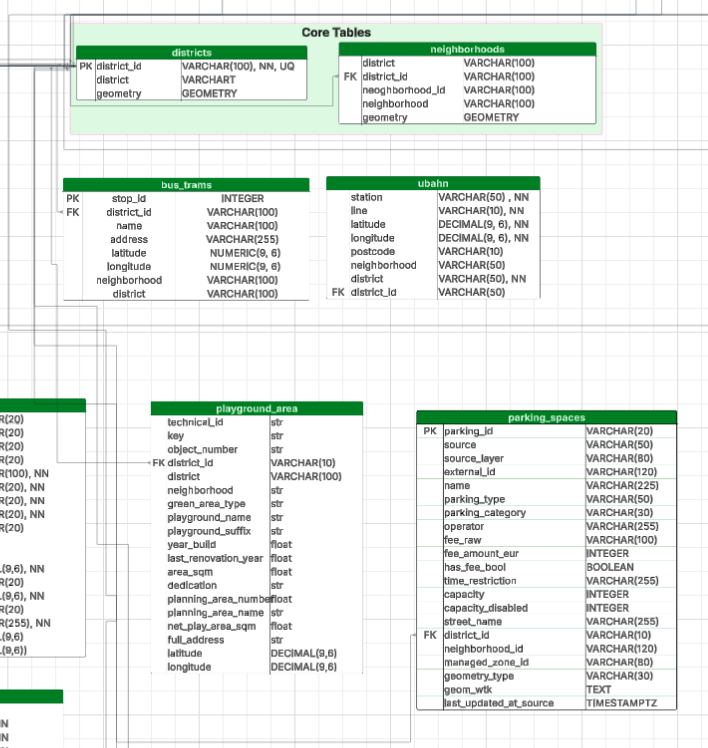